In [3]:
%pip install torch


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


In [5]:
%pip install tiktoken pandas numpy scikit-learn matplotlib

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
df = pd.read_csv("/content/IMDB Dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [12]:
df = df.sample(n=3000, random_state=42).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)

Sampled dataset shape: (3000, 2)


In [13]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "label"]].head(10))

  sentiment  label
0  positive      1
1  positive      1
2  negative      0
3  positive      1
4  negative      0
5  positive      1
6  positive      1
7  positive      1
8  negative      0
9  negative      0


In [14]:
X = df["review"].values
y = df["label"].values

print("Reviews:", len(X))
print("Labels:", len(y))

Reviews: 3000
Labels: 3000


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2400
Testing samples: 600


In [16]:
encoding = tiktoken.get_encoding("cl100k_base")

print("Tokenizer loaded successfully!")
print("Vocabulary size:", encoding.n_vocab)


Tokenizer loaded successfully!
Vocabulary size: 100277


In [17]:
X_train_tokens = [
    encoding.encode(review)
    for review in X_train
]

X_test_tokens = [
    encoding.encode(review)
    for review in X_test
]

print("Original review:")
print(X_train[0][:300])

print("\nFirst 30 token IDs:")
print(X_train_tokens[0][:30])

Original review:
Well...I like this movie first of all because it's very well thought of... and well..because the um...director and others chose an extremely great actor to play Mike....and also my last reason because ( my opinion) Elijah Wood is so so hot!!!

First 30 token IDs:
[11649, 1131, 40, 1093, 420, 5818, 1176, 315, 682, 1606, 433, 596, 1633, 1664, 3463, 315, 1131, 323, 1664, 497, 28753, 279, 4543, 1131, 70895, 323, 3885, 14896, 459, 9193]


In [18]:
train_lengths = [len(seq) for seq in X_train_tokens]

print("Shortest review:", min(train_lengths))
print("Longest review:", max(train_lengths))
print("Average token length:", round(np.mean(train_lengths), 2))

Shortest review: 33
Longest review: 1460
Average token length: 297.3


In [19]:
MAX_LENGTH = 200
PAD_TOKEN = 0

def pad_sequences(sequences, max_length):
    padded = []

    for seq in sequences:

        if len(seq) > max_length:
            seq = seq[:max_length]

        else:
            seq = seq + [PAD_TOKEN] * (max_length - len(seq))

        padded.append(seq)

    return np.array(padded, dtype=np.int64)

print("Maximum sequence length:", MAX_LENGTH)

Maximum sequence length: 200


In [20]:
X_train_padded = pad_sequences(
    X_train_tokens,
    MAX_LENGTH
)

X_test_padded = pad_sequences(
    X_test_tokens,
    MAX_LENGTH
)

print("Training shape:", X_train_padded.shape)
print("Testing shape:", X_test_padded.shape)

Training shape: (2400, 200)
Testing shape: (600, 200)


In [21]:
X_train_tensor = torch.tensor(
    X_train_padded,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_padded,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([2400, 200])
y_train: torch.Size([2400])
X_test: torch.Size([600, 200])
y_test: torch.Size([600])


In [22]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 75
Testing batches: 19


In [23]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 75
Testing batches: 19


In [24]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [25]:
class RNNClassifier(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_TOKEN
        )

        # RNN layer
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Linear output layer
        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        # Convert token IDs into embeddings
        embedded = self.embedding(x)

        # Pass embeddings through RNN
        output, hidden = self.rnn(embedded)

        # Take the final hidden state
        last_hidden = hidden[-1]

        # Linear classification layer
        output = self.fc(last_hidden)

        return output.squeeze(1)

In [26]:
VOCAB_SIZE = encoding.n_vocab
EMBEDDING_DIM = 64
HIDDEN_DIM = 64

model = RNNClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM
)

model = model.to(device)

print(model)

RNNClassifier(
  (embedding): Embedding(100277, 64, padding_idx=0)
  (rnn): RNN(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [27]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer: Adam")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam


In [34]:
EPOCHS = 15

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    loss_history.append(average_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/15] Loss: 0.3119
Epoch [2/15] Loss: 0.3023
Epoch [3/15] Loss: 0.2965
Epoch [4/15] Loss: 0.2907
Epoch [5/15] Loss: 0.2814
Epoch [6/15] Loss: 0.2932
Epoch [7/15] Loss: 0.3089
Epoch [8/15] Loss: 0.3046
Epoch [9/15] Loss: 0.3210
Epoch [10/15] Loss: 0.3485
Epoch [11/15] Loss: 0.3369
Epoch [12/15] Loss: 0.3003
Epoch [13/15] Loss: 0.2909
Epoch [14/15] Loss: 0.2847
Epoch [15/15] Loss: 0.3014


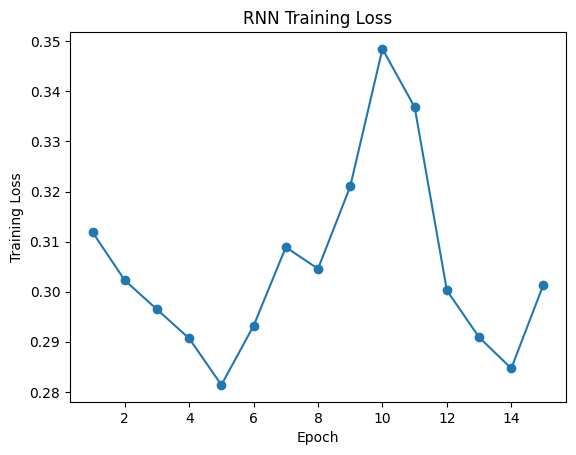

In [35]:
import matplotlib.pyplot as plt

plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("RNN Training Loss")

plt.show()

In [36]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_X)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        correct += (
            predictions == batch_y
        ).sum().item()

        total += batch_y.size(0)

accuracy = correct / total

print("Correct predictions:", correct)
print("Total test samples:", total)
print("Test Accuracy:", round(accuracy, 4))
print("Test Accuracy (%):", round(accuracy * 100, 2))

Correct predictions: 323
Total test samples: 600
Test Accuracy: 0.5383
Test Accuracy (%): 53.83


In [37]:
def predict_sentiment(review):

    model.eval()

    # Tokenize
    tokens = encoding.encode(review)

    # Pad
    padded = pad_sequences(
        [tokens],
        MAX_LENGTH
    )

    # Convert to tensor
    tensor = torch.tensor(
        padded,
        dtype=torch.long
    ).to(device)

    # Prediction
    with torch.no_grad():

        output = model(tensor)

        probability = torch.sigmoid(output).item()

    if probability >= 0.5:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"

    print("Review:")
    print(review)

    print("\nPositive probability:", round(probability, 4))
    print("Prediction:", sentiment)

In [38]:
predict_sentiment(
    "This movie was absolutely wonderful. "
    "The acting was excellent and I really enjoyed it."
)

Review:
This movie was absolutely wonderful. The acting was excellent and I really enjoyed it.

Positive probability: 0.5675
Prediction: POSITIVE


In [39]:
predict_sentiment(
    "This movie was extremely boring and disappointing. "
    "The story was terrible and the acting was very poor."
)

Review:
This movie was extremely boring and disappointing. The story was terrible and the acting was very poor.

Positive probability: 0.4919
Prediction: NEGATIVE
